# Adaptive transfer on DSA (Zhang et al., PyHealth)

Notebook companion to adaptive multi-source transfer on the UCI Daily and Sports Activities dataset. Uses `AdaptiveTransferModel`, `Trainer`, and optional DTW-based IPD (NumPy + optional `KernelDensity`) or embedding IPD via `compute_ipd`.

**Setup:** `pip install -e .`, set `DSA_ROOT` to the DSA tree (default: `HealthTimeSerial/data` under the repo), install `jupyter` / `matplotlib` as needed.


In [1]:
!pip install pyts==0.13.0

In [2]:
from __future__ import annotations

import os
import random
import sys
import warnings
from itertools import chain
from pathlib import Path
from typing import Callable, Dict, List, Optional, Sequence, Set, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.spatial.distance as spd
import torch
import torch.nn.functional as F
from sklearn.neighbors import KernelDensity

from pyts.metrics import dtw

warnings.filterwarnings("ignore", category=UserWarning)

_CWD = Path.cwd().resolve()
if (_CWD / "pyhealth").is_dir():
    REPO_ROOT = _CWD
elif (_CWD.parent / "pyhealth").is_dir():
    REPO_ROOT = _CWD.parent
else:
    raise FileNotFoundError("Run from the PyHealth repo root or from examples/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from pyhealth.datasets import DSADataset, create_sample_dataset, get_dataloader, split_by_patient
from pyhealth.datasets.utils import collate_fn_dict_with_padding
from pyhealth.metrics import multiclass_metrics_fn
from pyhealth.models.adaptive_transfer import AdaptiveTransferModel
from pyhealth.tasks import DSAActivityClassification
from pyhealth.trainer import Trainer

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": 0.3})
print("Python:", sys.executable)
print("Repo root:", REPO_ROOT)


/Users/tomiyoshi/DataspellProjects/PyHealth/.venv-test/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /Users/tomiyoshi/DataspellProjects/PyHealth/.venv-test/bin/python
Repo root: /Users/tomiyoshi/DataspellProjects/PyHealth


In [3]:
DSA_ROOT = Path(os.environ.get("DSA_ROOT", REPO_ROOT / "HealthTimeSerial" / "data")).resolve()
TARGET_UNIT = "LL"
ALL_UNITS = ("T", "RA", "LA", "RL", "LL")
SOURCE_UNITS = tuple(u for u in ALL_UNITS if u != TARGET_UNIT)

SEED = 598
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
BATCH_SIZE = 64
HIDDEN_DIM = 64
NUM_LAYERS = 1
DROPOUT = 0.2

EPOCHS_PROBE = 2
EPOCHS_PRETRAIN_PER_SOURCE = 4
EPOCHS_FINETUNE = 12

BINARY_REPS = 5
BINARY_BATCH = 16
MAX_IPD_TRAIN_SAMPLES = 350
PROBE_EMBEDDING_EPOCHS = 1
INFORMS_TRAIN_SUBJECTS = 6

IPD_METRIC = "dtw"  # "dtw" | "embedding"
IPD_USE_PAPER_KDE = True
IPD_KDE_BANDWIDTH = 7.8
IPD_KDE_DRAWS = 10
IPD_KDE_RANDOM_STATE = 0
IPD_USE_GAUSSIAN_NOISE = True
IPD_KDE_NOISE_STD = 0.01

RUN_FULL_ABLATION_GRID = False

if not DSA_ROOT.is_dir():
    raise FileNotFoundError(f"DSA_ROOT not found: {DSA_ROOT}")

print("DSA_ROOT:", DSA_ROOT)
print("TARGET_UNIT:", TARGET_UNIT, "| SOURCES:", SOURCE_UNITS)
print("Epochs (probe / pretrain / finetune):", EPOCHS_PROBE, EPOCHS_PRETRAIN_PER_SOURCE, EPOCHS_FINETUNE)
print("DEVICE:", DEVICE)


DSA_ROOT: /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data
TARGET_UNIT: LL | SOURCES: ('T', 'RA', 'LA', 'RL')
Epochs (probe / pretrain / finetune): 2 2 8
DEVICE: mps


In [26]:
# --- helpers ---


def _patients_in(ds) -> Set:
    out = set()
    for i in range(len(ds)):
        pid = ds[i]["patient_id"]
        if isinstance(pid, bytes):
            pid = pid.decode()
        out.add(pid)
    return out


def subset_for_patients(ds, patients: Set):
    idx = list(chain.from_iterable(ds.patient_to_index[p] for p in patients))
    return ds.subset(idx)


def batches_from_dataset(ds, batch_size: int) -> List[dict]:
    out = []
    for i in range(0, len(ds), batch_size):
        rows = [ds[j] for j in range(i, min(i + batch_size, len(ds)))]
        out.append(collate_fn_dict_with_padding(rows))
    return out


def _aggregate_ipd(distances: np.ndarray, *, use_paper_kde: bool, rng: Optional[np.random.Generator]) -> float:
    d = np.asarray(distances, dtype=np.float64).ravel()
    if d.size == 0:
        return 0.0
    if use_paper_kde:
        kde = KernelDensity(kernel="gaussian", bandwidth=IPD_KDE_BANDWIDTH).fit(d.reshape(-1, 1))
        return float(np.mean(kde.sample(IPD_KDE_DRAWS, random_state=IPD_KDE_RANDOM_STATE)))
    if IPD_USE_GAUSSIAN_NOISE:
        rng = rng or np.random.default_rng()
        d = np.maximum(d + rng.normal(0.0, IPD_KDE_NOISE_STD, size=d.shape), 0.0)
    return float(np.mean(d))


def mean_ipd(
    ipd_model: Optional[AdaptiveTransferModel],
    ds_src,
    ds_tgt,
    *,
    use_paper_kde: Optional[bool] = None,
    batch_size: int = 64,
    rng: Optional[np.random.Generator] = None,
) -> float:
    use_pk = IPD_USE_PAPER_KDE if use_paper_kde is None else bool(use_paper_kde)
    if len(ds_src) != len(ds_tgt):
        raise ValueError("Paired IPD requires datasets of equal length.")
    if IPD_METRIC == "embedding":
        if ipd_model is None:
            raise ValueError("IPD_METRIC='embedding' requires a probe model.")
        ipd_model.eval()
        vals = []
        for a, b in zip(batches_from_dataset(ds_src, batch_size), batches_from_dataset(ds_tgt, batch_size)):
            vals.append(ipd_model.compute_ipd(a, b))
        return float(np.mean(vals))
    all_d = []
    for a, b in zip(batches_from_dataset(ds_src, batch_size), batches_from_dataset(ds_tgt, batch_size)):
        xs, ys = a['signal'][0], b['signal'][0]
        for i in range(xs.shape[0]):
            all_d.append(dtw(xs[i], ys[i]))
    return _aggregate_ipd(np.array(all_d), use_paper_kde=use_pk, rng=rng)


def ranked_sources_ipd(ipd_model, bundles_map: dict, val_ds, *, use_paper_kde: Optional[bool] = None):
    dist = {s: mean_ipd(ipd_model, bundles_map[s]["val"], val_ds, use_paper_kde=use_paper_kde) for s in SOURCE_UNITS}
    order = sorted(SOURCE_UNITS, key=lambda u: dist[u])
    return order, dist


def ipd_matrix(ipd_model, bundles_map: dict, units: Sequence[str]):
    u = list(units)
    mat = np.zeros((len(u), len(u)))
    for i, a in enumerate(u):
        for j, b in enumerate(u):
            if i != j:
                mat[i, j] = mean_ipd(ipd_model, bundles_map[a]["val"], bundles_map[b]["val"])
    return mat


def fit(model, train_loader, val_loader, epochs: int, lr: float, monitor: str = "accuracy") -> None:
    Trainer(model=model, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        epochs=epochs,
        optimizer_params={"lr": lr},
        monitor=monitor,
        load_best_model_at_last=False,
    )


def accuracy(model, test_loader) -> float:
    t = Trainer(model=model, device=DEVICE, metrics=["accuracy"], enable_logging=False)
    return float(t.evaluate(test_loader)["accuracy"])


def transfer_experiment(
    pretrain_order: Sequence[str],
    *,
    no_transfer: bool = False,
    adaptive_lr: bool = True,
    base_lr: float = 1e-3,
    ipd_probe: Optional[AdaptiveTransferModel] = None,
    ipd_use_paper_kde: Optional[bool] = None,
    model_distance: Union[str, Callable[[torch.Tensor, torch.Tensor], torch.Tensor]] = "euclidean",
    use_kde_smoothing: bool = True,
    use_similarity_weighting: bool = True,
) -> float:
    ipd_ref = ipd_probe if ipd_probe is not None else probe
    tgt_va = bundles[TARGET_UNIT]["val"]
    tgt_tr = bundles[TARGET_UNIT]["train"]
    tgt_te = bundles[TARGET_UNIT]["test"]
    tr_l = get_dataloader(tgt_tr, batch_size=BATCH_SIZE, shuffle=True)
    va_l = get_dataloader(tgt_va, batch_size=BATCH_SIZE, shuffle=False)
    te_l = get_dataloader(tgt_te, batch_size=BATCH_SIZE, shuffle=False)

    model = AdaptiveTransferModel(
        dataset=tgt_tr,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        distance_fn=model_distance,
        use_similarity_weighting=use_similarity_weighting,
        use_kde_smoothing=use_kde_smoothing,
    ).to(DEVICE)

    if no_transfer:
        total = EPOCHS_PRETRAIN_PER_SOURCE * len(SOURCE_UNITS) + EPOCHS_FINETUNE
        fit(model, tr_l, va_l, total, base_lr)
        return accuracy(model, te_l)

    for src in pretrain_order:
        d = mean_ipd(ipd_ref, bundles[src]["val"], tgt_va, use_paper_kde=ipd_use_paper_kde)
        sim = 1.0 / (d + 1e-8)
        lr = model.get_adaptive_lr(base_lr, sim) if adaptive_lr else base_lr
        s_tr = get_dataloader(bundles[src]["train"], batch_size=BATCH_SIZE, shuffle=True)
        s_va = get_dataloader(bundles[src]["val"], batch_size=BATCH_SIZE, shuffle=False)
        fit(model, s_tr, s_va, EPOCHS_PRETRAIN_PER_SOURCE, lr)

    fit(model, tr_l, va_l, EPOCHS_FINETUNE, base_lr)
    return accuracy(model, te_l)


def accuracy_vs_noise(model, test_loader, noise_stds: Sequence[float]) -> List[float]:
    model.eval()
    out = []
    for std in noise_stds:
        ys, ps = [], []
        for data in test_loader:
            data = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v) for k, v in data.items()}
            if std > 0:
                sig = data["signal"]
                data = {**data, "signal": sig + torch.randn_like(sig) * std}
            with torch.no_grad():
                o = model(**data)
            ys.append(o["y_true"].cpu().numpy())
            ps.append(o["y_prob"].cpu().numpy())
        sc = multiclass_metrics_fn(np.concatenate(ys), np.concatenate(ps), metrics=["accuracy"])
        out.append(float(sc["accuracy"]))
    return out


def kulczynski_pairwise(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    xn = x.detach().float().cpu().numpy()
    yn = y.detach().float().cpu().numpy()
    vals = np.empty(x.shape[0], dtype=np.float64)
    for i in range(x.shape[0]):
        a = xn[i] >= np.median(xn[i])
        b = yn[i] >= np.median(yn[i])
        jac = spd.jaccard(a, b)
        vals[i] = 1 / (1 - jac) - 1 if jac < 1 else float('inf')
    return torch.as_tensor(vals, device=x.device, dtype=x.dtype)

def dtw_pairwise(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    xn = x.detach().float().cpu().numpy()
    yn = y.detach().float().cpu().numpy()
    vals = np.empty(x.shape[0], dtype=np.float64)
    for i in range(x.shape[0]):
        a = xn[i] >= np.median(xn[i])
        b = yn[i] >= np.median(yn[i])
        vals[i] = dtw(a, b)
    return torch.as_tensor(vals, device=x.device, dtype=x.dtype)


In [5]:
base_dsa = DSADataset(root=str(DSA_ROOT), num_workers=1)
_template_task = DSAActivityClassification(dataset_root=str(DSA_ROOT), selected_units=(ALL_UNITS[0],))
template_full = base_dsa.set_task(_template_task, num_workers=1)
train_ref, val_ref, test_ref = split_by_patient(template_full, [0.5, 0.25, 0.25], seed=SEED)
train_patients, val_patients, test_patients = map(_patients_in, (train_ref, val_ref, test_ref))

bundles = {}
for u in ALL_UNITS:
    task = DSAActivityClassification(dataset_root=str(DSA_ROOT), selected_units=(u,))
    full = base_dsa.set_task(task, num_workers=1)
    bundles[u] = {
        "full": full,
        "train": subset_for_patients(full, train_patients),
        "val": subset_for_patients(full, val_patients),
        "test": subset_for_patients(full, test_patients),
    }

val_tgt = bundles[TARGET_UNIT]["val"]
for u in ALL_UNITS:
    for i in (0, 1000, min(9000, len(bundles[u]["full"]) - 1)):
        assert bundles[u]["full"][i]["sample_id"] == bundles[ALL_UNITS[0]]["full"][i]["sample_id"]
print("Sample alignment OK | train/val/test:", len(bundles[TARGET_UNIT]["train"]), len(val_tgt), len(bundles[TARGET_UNIT]["test"]))

probe: Optional[AdaptiveTransferModel] = None
if IPD_METRIC == "embedding":
    probe = AdaptiveTransferModel(
        dataset=bundles[TARGET_UNIT]["train"],
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        distance_fn="euclidean",
        use_similarity_weighting=True,
        use_kde_smoothing=True,
    ).to(DEVICE)
    fit(
        probe,
        get_dataloader(bundles[TARGET_UNIT]["train"], batch_size=BATCH_SIZE, shuffle=True),
        get_dataloader(bundles[TARGET_UNIT]["val"], batch_size=BATCH_SIZE, shuffle=False),
        EPOCHS_PROBE,
        1e-3,
    )
else:
    print("IPD_METRIC=dtw: skip probe.")

ranked_sources, src_to_tgt_ipd = ranked_sources_ipd(probe, bundles, val_tgt)
canonical_source_order = list(SOURCE_UNITS)
random_order = canonical_source_order.copy()
random.Random(SEED).shuffle(random_order)
print("IPD-ranked sources:", ranked_sources)
print("IPD to target:", {k: round(v, 4) for k, v in src_to_tgt_ipd.items()})


No config path provided, using default config
Initializing dsa dataset from /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task

## 1) Paper-style experiments

### 1.1 INFORMS-style binary DSA (RCC)

Repeated runs with a random one-vs-rest positive class, balanced train/val, IPD on paired training segments, then no transfer / direct / adaptive IPD.


In [6]:
base_informs = DSADataset(root=str(DSA_ROOT), num_workers=1)
ds_by_unit = {
    u: base_informs.set_task(
        DSAActivityClassification(dataset_root=str(DSA_ROOT), selected_units=(u,)), num_workers=1
    )
    for u in ALL_UNITS
}
all_subjects = sorted(ds_by_unit[TARGET_UNIT].patient_to_index.keys())
assert len(all_subjects) == 8, f"Expected 8 DSA subjects, got {len(all_subjects)}"

informs_results: Dict[str, List[float]] = {"no_transfer": [], "direct_transfer": [], "adaptive_ipd": []}


def _binary_rows(sample_ds, subjects: Set, positive_class: int) -> List[dict]:
    rows = []
    for i in range(len(sample_ds)):
        s = sample_ds[i]
        pid = s["patient_id"]
        if isinstance(pid, bytes):
            pid = pid.decode()
        if pid not in subjects:
            continue
        sig = s["signal"]
        if hasattr(sig, "detach"):
            sig = sig.cpu().float().numpy()
        y = int(s["label"].item()) if hasattr(s["label"], "item") else int(s["label"])
        rows.append({"patient_id": pid, "visit_id": str(s.get("sample_id", "")), "signal": sig, "label": int(y == positive_class)})
    return rows


def _bootstrap_balance(samples: List[dict], rng: np.random.Generator) -> List[dict]:
    pos = [s for s in samples if s["label"] == 1]
    neg = [s for s in samples if s["label"] == 0]
    if not pos or not neg:
        return samples
    if len(pos) < len(neg):
        pos = [dict(pos[i]) for i in rng.integers(0, len(pos), size=len(neg))]
    elif len(neg) < len(pos):
        neg = [dict(neg[i]) for i in rng.integers(0, len(neg), size=len(pos))]
    out = pos + neg
    rng.shuffle(out)
    return out


def _balance_val(samples: List[dict], rng: np.random.Generator) -> List[dict]:
    pos = [s for s in samples if s["label"] == 1]
    neg = [s for s in samples if s["label"] == 0]
    if not pos or not neg:
        return samples
    n = min(len(pos), len(neg))
    rng.shuffle(pos)
    rng.shuffle(neg)
    out = pos[:n] + neg[:n]
    rng.shuffle(out)
    return out


def _train_indices_for_subjects(sample_ds, subjects: Set) -> List[int]:
    idx = []
    for i in range(len(sample_ds)):
        pid = sample_ds[i]["patient_id"]
        if isinstance(pid, bytes):
            pid = pid.decode()
        if pid in subjects:
            idx.append(i)
    return idx


for rep in range(BINARY_REPS):
    rng = np.random.default_rng(SEED + rep * 997)
    sid = list(all_subjects)
    np.random.default_rng(SEED + rep * 13).shuffle(sid)
    train_subj, val_subj = set(sid[:INFORMS_TRAIN_SUBJECTS]), set(sid[INFORMS_TRAIN_SUBJECTS:])
    pos_class = int(rng.integers(0, 19))

    train_ds_u, val_ds_u = {}, {}
    for u in ALL_UNITS:
        raw_tr = _bootstrap_balance(_binary_rows(ds_by_unit[u], train_subj, pos_class), rng)
        raw_va = _balance_val(_binary_rows(ds_by_unit[u], val_subj, pos_class), rng)
        if not raw_tr or not raw_va:
            train_ds_u[u] = None
            val_ds_u[u] = None
            continue
        train_ds_u[u] = create_sample_dataset(raw_tr, {"signal": "tensor"}, {"label": "multiclass"}, f"tr_{rep}_{u}", in_memory=True)
        val_ds_u[u] = create_sample_dataset(raw_va, {"signal": "tensor"}, {"label": "multiclass"}, f"va_{rep}_{u}", in_memory=True)

    if any(train_ds_u[u] is None for u in ALL_UNITS):
        print(f"rep {rep}: skip (empty domain); pos=A{pos_class + 1:02d}")
        continue

    idx_ipd = _train_indices_for_subjects(ds_by_unit[TARGET_UNIT], train_subj)
    rng.shuffle(idx_ipd)
    idx_ipd = idx_ipd[: min(len(idx_ipd), MAX_IPD_TRAIN_SAMPLES)]

    ipd_model: Optional[AdaptiveTransferModel] = None
    if IPD_METRIC == "embedding":
        ipd_model = AdaptiveTransferModel(
            dataset=train_ds_u[TARGET_UNIT],
            feature_key="signal",
            hidden_dim=64,
            num_layers=1,
            dropout=0.2,
            backbone="lstm",
            distance_fn="euclidean",
            use_similarity_weighting=True,
            use_kde_smoothing=True,
        ).to(DEVICE)
        if PROBE_EMBEDDING_EPOCHS > 0:
            fit(
                ipd_model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                PROBE_EMBEDDING_EPOCHS,
                1e-3,
            )

    ipd_src_to_tgt = {}
    for s in SOURCE_UNITS:
        vals, alld = [], []
        for i in range(0, len(idx_ipd), 48):
            chunk = idx_ipd[i : i + 48]
            ba = collate_fn_dict_with_padding([ds_by_unit[s][j] for j in chunk])
            bb = collate_fn_dict_with_padding([ds_by_unit[TARGET_UNIT][j] for j in chunk])
            if IPD_METRIC == "embedding":
                assert ipd_model is not None
                vals.append(ipd_model.compute_ipd(ba, bb))
            else:
                xs, ys = ba['signal'][0], bb['signal'][0]
            for k in range(xs.shape[0]):
                alld.append(dtw(xs[k], ys[k]))
        ipd_src_to_tgt[s] = float(np.mean(vals)) if IPD_METRIC == "embedding" else _aggregate_ipd(np.array(alld), use_paper_kde=IPD_USE_PAPER_KDE, rng=rng)

    ranked_rep = sorted(SOURCE_UNITS, key=lambda u: ipd_src_to_tgt[u])
    total_target_epochs = EPOCHS_PRETRAIN_PER_SOURCE * len(SOURCE_UNITS) + EPOCHS_FINETUNE
    base_lr = 5e-3

    for mode in ("no_transfer", "direct_transfer", "adaptive_ipd"):
        model = AdaptiveTransferModel(
            dataset=train_ds_u[TARGET_UNIT],
            feature_key="signal",
            hidden_dim=64,
            num_layers=1,
            dropout=0.2,
            backbone="lstm",
            use_similarity_weighting=(mode == "adaptive_ipd"),
            use_kde_smoothing=True,
        ).to(DEVICE)

        if mode == "no_transfer":
            fit(
                model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                total_target_epochs,
                base_lr,
            )
        elif mode == "direct_transfer":
            for s in SOURCE_UNITS:
                fit(
                    model,
                    get_dataloader(train_ds_u[s], batch_size=BINARY_BATCH, shuffle=True),
                    get_dataloader(val_ds_u[s], batch_size=BINARY_BATCH, shuffle=False),
                    EPOCHS_PRETRAIN_PER_SOURCE,
                    base_lr,
                )
            fit(
                model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                EPOCHS_FINETUNE,
                base_lr,
            )
        else:
            for s in ranked_rep:
                lr = model.get_adaptive_lr(base_lr, 1.0 / (ipd_src_to_tgt[s] + 1e-8))
                fit(
                    model,
                    get_dataloader(train_ds_u[s], batch_size=BINARY_BATCH, shuffle=True),
                    get_dataloader(val_ds_u[s], batch_size=BINARY_BATCH, shuffle=False),
                    EPOCHS_PRETRAIN_PER_SOURCE,
                    lr,
                )
            fit(
                model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                EPOCHS_FINETUNE,
                base_lr,
            )

        acc = accuracy(model, get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False))
        informs_results[mode].append(acc)
        print(f"rep {rep} {mode}: pos=A{pos_class + 1:02d} RCC={acc:.4f} | IPD rank: {ranked_rep}")

del base_informs, ds_by_unit


No config path provided, using default config
Initializing dsa dataset from /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task

Epoch 0 / 16: 100%|██████████| 810/810 [00:09<00:00, 87.36it/s]

--- Train epoch-0, step-810 ---
loss: 0.4542



Evaluation: 100%|██████████| 15/15 [00:00<00:00, 190.02it/s]

--- Eval epoch-0, step-810 ---
accuracy: 0.8250
loss: 0.4480
New best accuracy score (0.8250) at epoch-0, step-810



...

--- Train epoch-7, step-6480 ---
loss: 0.0248



Evaluation: 100%|██████████| 15/15 [00:00<00:00, 215.37it/s]

--- Eval epoch-7, step-6480 ---
accuracy: 0.7333
loss: 1.0422
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 15/15 [00:00<00:00, 162.38it/s]

rep 4 adaptive_ipd: pos=A04 RCC=0.7333 | IPD rank: ['RA', 'T', 'RL', 'LA']


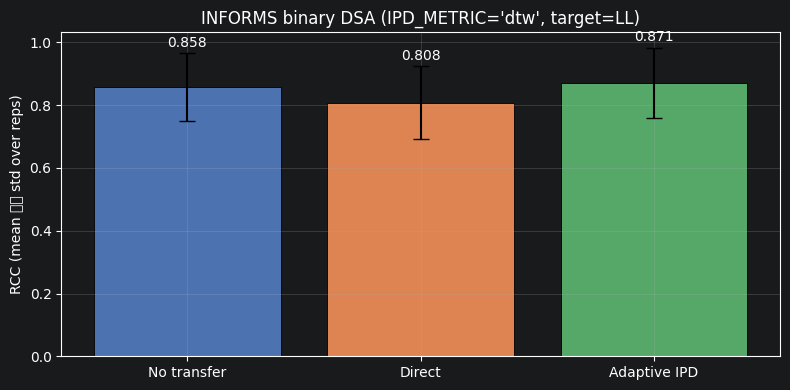

,condition,mean_rcc,std_rcc
0,No transfer,0.858333,0.107787
1,Direct,0.808333,0.117349
2,Adaptive IPD,0.870833,0.112268


Per-rep: {'no_transfer': [0.7708333333333334, 0.9666666666666667, 1.0, 0.8291666666666667, 0.725], 'direct_transfer': [0.775, 0.7625, 1.0, 0.8583333333333333, 0.6458333333333334], 'adaptive_ipd': [0.75, 0.9875, 0.9958333333333333, 0.8875, 0.7333333333333333]}


In [7]:
labels_short = ["No transfer", "Direct", "Adaptive IPD"]
keys = ["no_transfer", "direct_transfer", "adaptive_ipd"]
means = [float(np.mean(informs_results[k])) if informs_results[k] else 0.0 for k in keys]
stds = [float(np.std(informs_results[k])) if informs_results[k] else 0.0 for k in keys]
xpos = np.arange(len(keys))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xpos, means, yerr=stds, capsize=6, color=["#4c72b0", "#dd8452", "#55a868"], edgecolor="black", linewidth=0.6)
ax.set_xticks(xpos)
ax.set_xticklabels(labels_short)
ax.set_ylabel("RCC (mean ﷿﷿ std over reps)")
ax.set_title(f"INFORMS binary DSA (IPD_METRIC={IPD_METRIC!r}, target={TARGET_UNIT})")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.02, f"{m:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

display(pd.DataFrame({"condition": labels_short, "mean_rcc": means, "std_rcc": stds}))
print("Per-rep:", {k: informs_results[k] for k in keys if informs_results[k]})


### 1.2 Domain IPD heatmap (validation split)


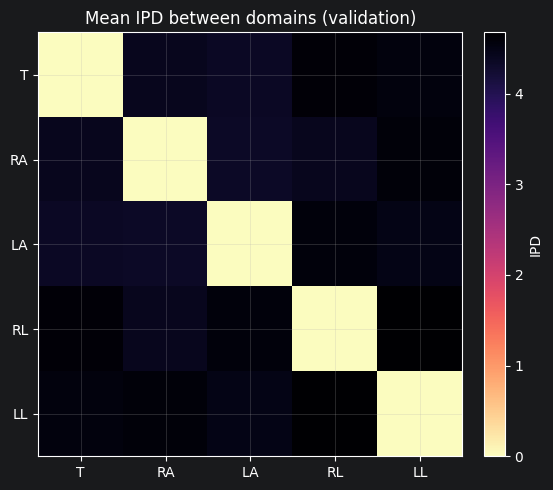

,T,RA,LA,RL,LL
T,0.000,4.410,4.351,4.606,4.558
RA,4.410,0.000,4.342,4.413,4.593
LA,4.351,4.342,0.000,4.568,4.490
RL,4.606,4.413,4.568,0.000,4.675
LL,4.558,4.593,4.490,4.675,0.000


In [8]:
ipd_mat = ipd_matrix(probe, bundles, ALL_UNITS)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ipd_mat, cmap="magma_r")
ax.set_xticks(range(len(ALL_UNITS)))
ax.set_yticks(range(len(ALL_UNITS)))
ax.set_xticklabels(ALL_UNITS)
ax.set_yticklabels(ALL_UNITS)
ax.set_title("Mean IPD between domains (validation)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="IPD")
plt.tight_layout()
plt.show()
display(pd.DataFrame(ipd_mat, index=list(ALL_UNITS), columns=list(ALL_UNITS)).round(3))


### 1.3 Multiclass DSA (19-class accuracy)


In [9]:
results_main = {}
results_main["no_transfer"] = transfer_experiment((), no_transfer=True)
results_main["direct_transfer"] = transfer_experiment(canonical_source_order, adaptive_lr=False)
results_main["adaptive_ipd_ranked"] = transfer_experiment(ranked_sources, adaptive_lr=True)
print(results_main)


AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14650a650>
Monitor: accuracy
Monitor criterion: max
Epochs: 16
Patience: None



Epoch 0 / 16: 100%|██████████| 72/72 [00:01<00:00, 55.94it/s]

--- Train epoch-0, step-72 ---
loss: 2.8968



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 130.35it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1044
loss: 2.7414
New best accuracy score (0.1044) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.1535



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 109.88it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.1921
loss: 2.4484
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 133.51it/s]

{'no_transfer': 0.2657894736842105, 'direct_transfer': 0.19649122807017544, 'adaptive_ipd_ranked': 0.20614035087719298}


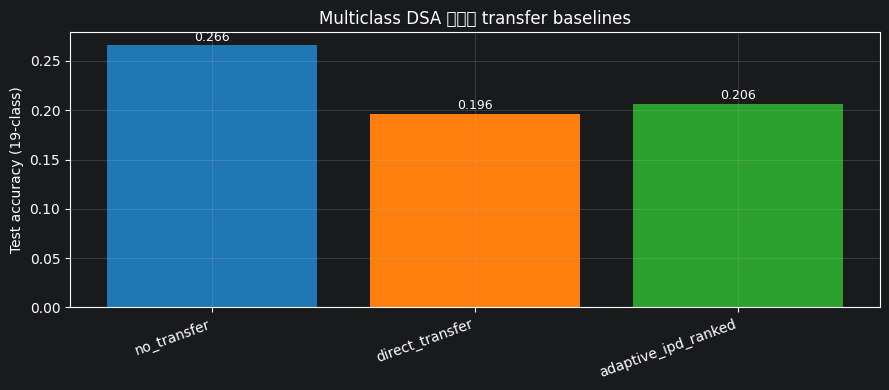

,setting,test_accuracy
0,no_transfer,0.2658
1,direct_transfer,0.1965
2,adaptive_ipd_ranked,0.2061


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
names = list(results_main.keys())
accs = [results_main[k] for k in names]
xpos = np.arange(len(names))
cmap = plt.get_cmap("tab10")
ax.bar(xpos, accs, color=[cmap(i % 10) for i in range(len(names))])
ax.set_xticks(xpos)
ax.set_ylabel("Test accuracy (19-class)")
ax.set_title("Multiclass DSA ﷿﷿﷿ transfer baselines")
ax.set_xticklabels(names, rotation=20, ha="right")
for i, v in enumerate(accs):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
display(pd.DataFrame({"setting": names, "test_accuracy": [round(v, 4) for v in accs]}))


## 2) Ablations

Each subsection changes one factor relative to the adaptive IPD baseline in `results_main`.


### 2.1 Random source order


In [11]:
acc_random = transfer_experiment(random_order, adaptive_lr=True)
ablation_h1 = {"adaptive_ipd_ranked": results_main["adaptive_ipd_ranked"], "random_source_order": acc_random}
print(ablation_h1)


AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.00021391344820508856}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14947ae50>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 63.70it/s]

--- Train epoch-0, step-72 ---
loss: 2.9445



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 131.91it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.0434
loss: 2.9396
New best accuracy score (0.0434) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.2705



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 126.81it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.2671
loss: 2.2191
New best accuracy score (0.2671) at epoch-7, step-576
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 116.29it/s]

{'adaptive_ipd_ranked': 0.20614035087719298, 'random_source_order': 0.2574561403508772}


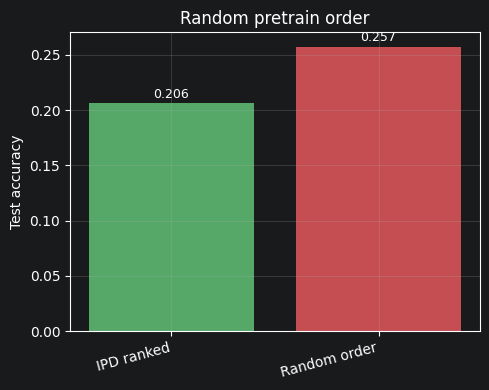

,test_accuracy
adaptive_ipd_ranked,0.206140
random_source_order,0.257456


In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = list(ablation_h1.keys())
vals = [ablation_h1[k] for k in labels]
ax.bar(range(len(labels)), vals, color=["#55a868", "#c44e52"])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(["IPD ranked", "Random order"], rotation=15, ha="right")
ax.set_ylabel("Test accuracy")
ax.set_title("Random pretrain order")
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
display(pd.DataFrame([ablation_h1]).T.rename(columns={0: "test_accuracy"}))


### 2.2 Fixed learning rate on sources (IPD order)


In [13]:
acc_fixed_lr = transfer_experiment(ranked_sources, adaptive_lr=False)
ablation_h2 = {"adaptive_ipd_ranked": results_main["adaptive_ipd_ranked"], "fixed_lr_ipd_order": acc_fixed_lr}
print(ablation_h2)


AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x1473d2150>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 62.04it/s]

--- Train epoch-0, step-72 ---
loss: 2.9225



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 133.85it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1456
loss: 2.8593
New best accuracy score (0.1456) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.3280



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 103.77it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.1952
loss: 2.4348
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 121.93it/s]

{'adaptive_ipd_ranked': 0.20614035087719298, 'fixed_lr_ipd_order': 0.19956140350877194}


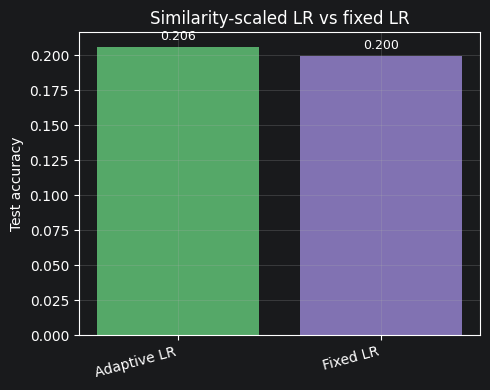

,test_accuracy
adaptive_ipd_ranked,0.206140
fixed_lr_ipd_order,0.199561


In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = list(ablation_h2.keys())
vals = [ablation_h2[k] for k in labels]
ax.bar(range(len(labels)), vals, color=["#55a868", "#8172b2"])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(["Adaptive LR", "Fixed LR"], rotation=15, ha="right")
ax.set_ylabel("Test accuracy")
ax.set_title("Similarity-scaled LR vs fixed LR")
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
display(pd.DataFrame([ablation_h2]).T.rename(columns={0: "test_accuracy"}))


### 2.3 DTW IPD: KDE aggregation vs plain mean


In [15]:
ranked_plain, _ = ranked_sources_ipd(probe, bundles, val_tgt, use_paper_kde=False)
acc_plain_ipd = transfer_experiment(ranked_plain, adaptive_lr=True, ipd_use_paper_kde=False)
ablation_kde = {"adaptive_ipd_ranked_kde": results_main["adaptive_ipd_ranked"], "adaptive_plain_mean_ipd": acc_plain_ipd}
print("Ranked (KDE):", ranked_sources)
print("Ranked (mean):", ranked_plain)
print(ablation_kde)


AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.0007167017848543378}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14779d350>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 64.62it/s]

--- Train epoch-0, step-72 ---
loss: 2.9312



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 142.78it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.0789
loss: 2.9171
New best accuracy score (0.0789) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.3237



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 141.74it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.2333
loss: 2.3650
New best accuracy score (0.2333) at epoch-7, step-576
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 110.29it/s]

Ranked (KDE): ['LA', 'T', 'RA', 'RL']
Ranked (mean): ['RL', 'T', 'LA', 'RA']
{'adaptive_ipd_ranked_kde': 0.20614035087719298, 'adaptive_plain_mean_ipd': 0.181140350877193}


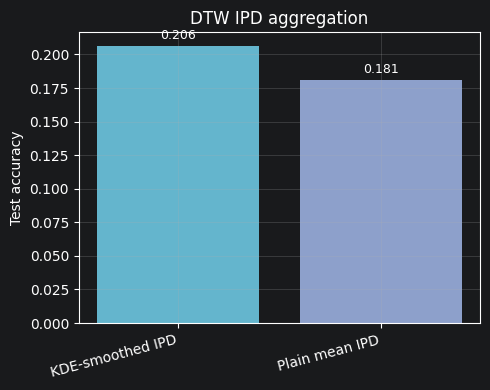

,test_accuracy
adaptive_ipd_ranked_kde,0.20614
adaptive_plain_mean_ipd,0.18114


In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
vs = [ablation_kde["adaptive_ipd_ranked_kde"], ablation_kde["adaptive_plain_mean_ipd"]]
ax.bar(range(2), vs, color=["#64b5cd", "#8da0cb"])
ax.set_xticks(range(2))
ax.set_xticklabels(["KDE-smoothed IPD", "Plain mean IPD"], rotation=15, ha="right")
ax.set_ylabel("Test accuracy")
ax.set_title("DTW IPD aggregation")
for i, v in enumerate(vs):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
display(pd.DataFrame([ablation_kde]).T.rename(columns={0: "test_accuracy"}))


### 2.4 Test-time Gaussian noise


In [17]:
tgt_te = bundles[TARGET_UNIT]["test"]
test_loader_noise = get_dataloader(tgt_te, batch_size=BATCH_SIZE, shuffle=False)
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3]


def train_for_noise(mode: str) -> AdaptiveTransferModel:
    tr = get_dataloader(bundles[TARGET_UNIT]["train"], batch_size=BATCH_SIZE, shuffle=True)
    va = get_dataloader(bundles[TARGET_UNIT]["val"], batch_size=BATCH_SIZE, shuffle=False)
    model = AdaptiveTransferModel(
        dataset=bundles[TARGET_UNIT]["train"],
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
    ).to(DEVICE)
    if mode == "no_transfer":
        fit(model, tr, va, EPOCHS_PRETRAIN_PER_SOURCE * len(SOURCE_UNITS) + EPOCHS_FINETUNE, 1e-3)
        return model
    for src in ranked_sources:
        sim = 1.0 / (mean_ipd(probe, bundles[src]["val"], bundles[TARGET_UNIT]["val"]) + 1e-8)
        lr = model.get_adaptive_lr(1e-3, sim)
        fit(
            model,
            get_dataloader(bundles[src]["train"], batch_size=BATCH_SIZE, shuffle=True),
            get_dataloader(bundles[src]["val"], batch_size=BATCH_SIZE, shuffle=False),
            EPOCHS_PRETRAIN_PER_SOURCE,
            lr,
        )
    fit(model, tr, va, EPOCHS_FINETUNE, 1e-3)
    return model


print("Training models for noise sweep ﷿﷿﷿")
m0 = train_for_noise("no_transfer")
acc_noise_0 = accuracy_vs_noise(m0, test_loader_noise, noise_levels)
m1 = train_for_noise("adaptive_ipd")
acc_noise_1 = accuracy_vs_noise(m1, test_loader_noise, noise_levels)


Training models for noise sweep ﷿﷿﷿
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x1473d2150>
Monitor: accuracy
Monitor criterion: max
Epochs: 16
Patience: None



Epoch 0 / 16: 100%|██████████| 72/72 [00:01<00:00, 55.06it/s]

--- Train epoch-0, step-72 ---
loss: 2.9023



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 146.85it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1553
loss: 2.7821
New best accuracy score (0.1553) at epoch-0, step-72



...

--- Eval epoch-6, step-504 ---
accuracy: 0.2667
loss: 2.1103
New best accuracy score (0.2667) at epoch-6, step-504




Epoch 7 / 8: 100%|██████████| 72/72 [00:01<00:00, 62.29it/s]

--- Train epoch-7, step-576 ---
loss: 2.0795



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 145.16it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.2211
loss: 2.2394


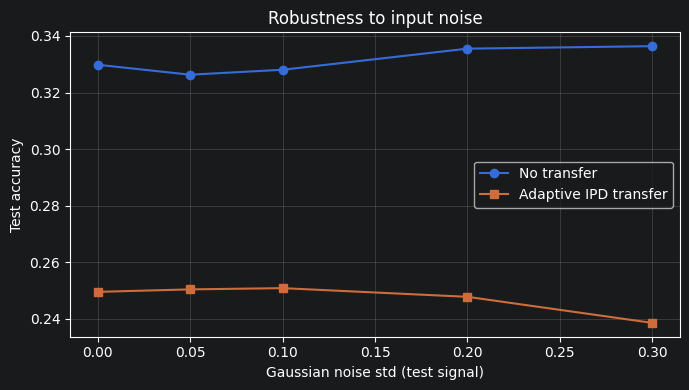

,noise_std,no_transfer,adaptive_ipd
0,0.00,0.329825,0.249561
1,0.05,0.326316,0.250439
2,0.10,0.328070,0.250877
3,0.20,0.335526,0.247807
4,0.30,0.336404,0.238596


In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(noise_levels, acc_noise_0, marker="o", label="No transfer")
ax.plot(noise_levels, acc_noise_1, marker="s", label="Adaptive IPD transfer")
ax.set_xlabel("Gaussian noise std (test signal)")
ax.set_ylabel("Test accuracy")
ax.set_title("Robustness to input noise")
ax.legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame({"noise_std": noise_levels, "no_transfer": acc_noise_0, "adaptive_ipd": acc_noise_1}))


### 2.5 Optional flag grid (`IPD_METRIC == "embedding"`)

Set `RUN_FULL_ABLATION_GRID = True` to sweep `distance_fn` / smoothing flags on the classifier (meaningful when IPD is embedding-based).


In [19]:
results_flag_grid: Dict[str, float] = {}
if RUN_FULL_ABLATION_GRID and IPD_METRIC == "embedding":
    grid = [
        ("adaptive_default", "euclidean", True, True),
        ("no_kde_smoothing", "euclidean", True, False),
        ("no_similarity_lr_model", "euclidean", False, True),
        ("distance_cosine", "cosine", True, True),
        ("distance_manhattan", "manhattan", True, True),
    ]
    for name, dist, sim_w, kde in grid:
        print("=== flag grid:", name, "===")
        results_flag_grid[name] = transfer_experiment(
            ranked_sources,
            adaptive_lr=sim_w,
            model_distance=dist,
            use_kde_smoothing=kde,
            use_similarity_weighting=sim_w,
        )
elif not RUN_FULL_ABLATION_GRID:
    print("Set RUN_FULL_ABLATION_GRID = True and IPD_METRIC='embedding' to run this grid.")
else:
    print("Skip: requires IPD_METRIC='embedding'.")


Set RUN_FULL_ABLATION_GRID = True and IPD_METRIC='embedding' to run this grid.


In [20]:
if results_flag_grid:
    fig, ax = plt.subplots(figsize=(10, 4))
    keys = list(results_flag_grid.keys())
    vals = [results_flag_grid[k] for k in keys]
    ax.bar(np.arange(len(keys)), vals, color="steelblue")
    ax.set_xticks(np.arange(len(keys)))
    ax.set_ylabel("Test accuracy")
    ax.set_title("Embedding-IPD flag ablations")
    ax.set_xticklabels(keys, rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame({"setting": keys, "test_accuracy": vals}))
else:
    print("No flag-grid results to plot.")


No flag-grid results to plot.


## 3) Embedding IPD: alternative probe distances

Temporarily uses `IPD_METRIC = "embedding"`, trains a probe per distance, recomputes source order, and runs `transfer_experiment` with that probe.


### 3.1 Probe distance sensitivity


In [27]:
_saved = IPD_METRIC
IPD_METRIC = "embedding"
extension_results: Dict[str, float] = {}
probe_tr = get_dataloader(bundles[TARGET_UNIT]["train"], batch_size=BATCH_SIZE, shuffle=True)
probe_va = get_dataloader(bundles[TARGET_UNIT]["val"], batch_size=BATCH_SIZE, shuffle=False)

distance_specs = [
    ("dtw", dtw_pairwise),
    ("euclidean", "euclidean"),
    ("minkowski_p3", lambda x, y: F.pairwise_distance(x, y, p=3)),
    ("kulczynski1_median_bin", kulczynski_pairwise),
]

for label, dist in distance_specs:
    probe_ext = AdaptiveTransferModel(
        dataset=bundles[TARGET_UNIT]["train"],
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        distance_fn=dist,
        use_similarity_weighting=True,
        use_kde_smoothing=True,
    ).to(DEVICE)
    fit(probe_ext, probe_tr, probe_va, EPOCHS_PROBE, 1e-3)
    rank_ext, _ = ranked_sources_ipd(probe_ext, bundles, val_tgt)
    print(f"=== extension {label} | rank {rank_ext} ===")
    extension_results[label] = transfer_experiment(rank_ext, adaptive_lr=True, ipd_probe=probe_ext)

IPD_METRIC = _saved
print("Restored IPD_METRIC to", IPD_METRIC)


AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x147628250>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 56.00it/s]

--- Train epoch-0, step-72 ---
loss: 2.8906



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 117.20it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1509
loss: 2.6794
New best accuracy score (0.1509) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.0828



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 114.63it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.2746
loss: 2.1241
New best accuracy score (0.2746) at epoch-7, step-576
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 131.76it/s]

Restored IPD_METRIC to embedding


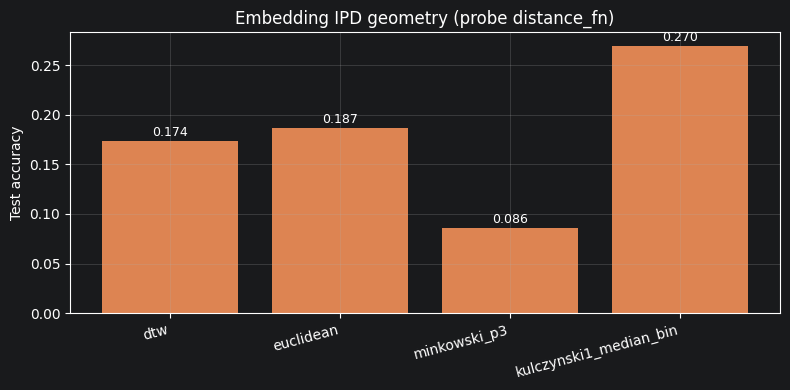

,distance,test_accuracy
0,dtw,0.1741
1,euclidean,0.1868
2,minkowski_p3,0.0860
3,kulczynski1_median_bin,0.2697


In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
keys = list(extension_results.keys())
vals = [extension_results[k] for k in keys]
ax.bar(np.arange(len(keys)), vals, color="#dd8452")
ax.set_xticks(np.arange(len(keys)))
ax.set_ylabel("Test accuracy")
ax.set_title("Embedding IPD geometry (probe distance_fn)")
ax.set_xticklabels(keys, rotation=15, ha="right")
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
display(pd.DataFrame({"distance": keys, "test_accuracy": [round(v, 4) for v in vals]}))


## References

- Barshan & Altun (2014). Daily and Sports Activities. UCI ML Repository.
- Zhang et al., *Daily Physical Activity Monitoring: Adaptive Learning from Multi-Source Motion Sensor Data*.
